# Convex Optimization & Duality
## From Theory to Algorithms — A Hands-On Exploration

---

**Author:** Computational Mathematics Notebook Series
**Topic:** Convex Optimization, Lagrangian Duality, and Conic Programming
**Prerequisites:** Linear algebra, multivariate calculus, basic Python/NumPy
**Primary Reference:** Boyd & Vandenberghe, *Convex Optimization* (Cambridge University Press, 2004)

In [1]:
%matplotlib inline

import numpy as np
from scipy import linalg as la
from scipy.optimize import minimize, linprog
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 2})

print("All imports successful.")

All imports successful.


In [2]:
# =============================================================================
# CONSTANTS
# =============================================================================

SEED = 42
np.random.seed(SEED)

# Tolerances
TOL_GD = 1e-8
TOL_NEWTON = 1e-12
TOL_KKT = 1e-8
TOL_DUALITY = 1e-6
TOL_QP = 1e-6

# Algorithm parameters
MAX_ITER_GD = 10000
MAX_ITER_NEWTON = 100
MAX_ITER_BARRIER = 50
BACKTRACK_ALPHA = 0.3
BACKTRACK_BETA = 0.8

# Colors
COLOR_PRIMARY = 'steelblue'
COLOR_SECONDARY = 'coral'
COLOR_TERTIARY = 'seagreen'
COLOR_ACCENT = 'goldenrod'
CMAP_EVOLUTION = 'viridis'

print("Constants defined.")

Constants defined.


---
## 1. Introduction — Why Convexity Matters

### The Fundamental Property

Convex optimization is special because **every local minimum is a global minimum**. This single property
transforms optimization from an intractable search into a solvable problem.

**Key consequences:**
- Efficient polynomial-time algorithms exist (interior-point methods)
- Duality theory provides certificates of optimality
- Sensitivity analysis is well-defined

### Standard Form

A convex optimization problem has the form:

$$
\boxed{
\begin{aligned}
\min_{x} \quad & f_0(x) \\
\text{s.t.} \quad & f_i(x) \leq 0, \quad i = 1, \ldots, m \\
& h_j(x) = 0, \quad j = 1, \ldots, p
\end{aligned}
}
$$

where $f_0, f_1, \ldots, f_m$ are **convex** and $h_1, \ldots, h_p$ are **affine**.

### Roadmap

| Section | Topic | Key Idea |
|---------|-------|----------|
| 2 | Convex Sets & Functions | Definitions, preservation rules, Hessian check |
| 3 | Unconstrained Optimization | GD, Newton, convergence rates |
| 4 | KKT Conditions | Lagrangian, optimality conditions |
| 5 | Lagrangian Duality | Weak/strong duality, Slater's condition |
| 6 | Quadratic Programming | Active-set method |
| 7 | SOCP | Barrier method, robot localization |
| 8 | SDP | Log-det barrier, sensor networks |
| 9 | Visualizations | Comprehensive plots |
| 10 | Extensions | ADMM, proximal methods, DCP |

---
## 2. Convex Sets & Functions

### Definitions

A set $C$ is **convex** if for all $x, y \in C$ and $\theta \in [0,1]$:

$$\theta x + (1-\theta) y \in C$$

A function $f: \mathbb{R}^n \to \mathbb{R}$ is **convex** if $\text{dom}(f)$ is convex and:

$$f(\theta x + (1-\theta) y) \leq \theta f(x) + (1-\theta) f(y)$$

### Second-Order Condition

$f$ is convex if and only if $\nabla^2 f(x) \succeq 0$ (positive semidefinite) for all $x \in \text{dom}(f)$.

### Operations Preserving Convexity

| Operation | Sets | Functions |
|-----------|------|-----------|
| Intersection | $C_1 \cap C_2$ convex | — |
| Affine image | $\{Ax + b : x \in C\}$ convex | $f(Ax+b)$ convex |
| Perspective | $\{x/t : (x,t) \in C, t>0\}$ convex | $tf(x/t)$ (perspective) |
| Non-neg weighted sum | — | $\sum w_i f_i$, $w_i \geq 0$ |
| Pointwise max | — | $\max_i f_i(x)$ convex |

In [3]:
# =============================================================================
# SECTION 2: Convexity Verification via Hessian Eigenvalues
# =============================================================================

def check_convexity_hessian(hessian_func, points, name="f"):
    """Check convexity by verifying the Hessian is PSD at sample points.

    Args:
        hessian_func: Callable that returns the Hessian matrix at a point.
            Signature: hessian_func(x) -> np.ndarray of shape (n, n).
        points: Array of sample points. Shape: (num_points, n).
        name: Name of the function for display.

    Returns:
        is_convex: bool, True if Hessian is PSD at all sample points.
        min_eigenvalues: Array of minimum eigenvalues at each point. Shape: (num_points,).
    """
    min_eigs = []
    for x in points:
        H = hessian_func(x)
        eigvals = np.linalg.eigvalsh(H)
        min_eigs.append(eigvals.min())
    min_eigs = np.array(min_eigs)
    is_convex = np.all(min_eigs >= -1e-10)
    return is_convex, min_eigs


# Example 1: f(x) = x^T Q x + c^T x  (quadratic with Q PSD)
np.random.seed(SEED)
n_dim = 3
A_rand = np.random.randn(n_dim, n_dim)
Q_PSD = A_rand.T @ A_rand + 0.1 * np.eye(n_dim)  # guaranteed PSD

def hessian_quadratic(x):
    return 2 * Q_PSD

points = np.random.randn(100, n_dim)
is_cvx, min_eigs = check_convexity_hessian(hessian_quadratic, points, "quadratic")
print(f"Quadratic f(x)=x'Qx: convex = {is_cvx}, min eigenvalue of Hessian = {min_eigs.min():.4f}")

# Example 2: f(x,y) = x^4 + y^4 - convex
def hessian_quartic(x):
    return np.diag([12*x[0]**2, 12*x[1]**2])

points_2d = np.random.randn(200, 2)
is_cvx2, min_eigs2 = check_convexity_hessian(hessian_quartic, points_2d, "quartic")
print(f"Quartic f(x,y)=x^4+y^4: convex = {is_cvx2}, min eigenvalue of Hessian = {min_eigs2.min():.6f}")

# Example 3: f(x,y) = x*y — NOT convex
def hessian_xy(x):
    return np.array([[0.0, 1.0], [1.0, 0.0]])

is_cvx3, min_eigs3 = check_convexity_hessian(hessian_xy, points_2d, "xy")
print(f"Bilinear f(x,y)=xy: convex = {is_cvx3}, min eigenvalue of Hessian = {min_eigs3.min():.4f}")

# Verification
status1 = "PASS" if is_cvx else "FAIL"
status2 = "PASS" if is_cvx2 else "FAIL"
status3 = "PASS" if not is_cvx3 else "FAIL"
print(f"\nconvexity_check: quadratic convex [{status1}]")
print(f"convexity_check: quartic convex [{status2}]")
print(f"convexity_check: bilinear non-convex [{status3}]")

Quadratic f(x)=x'Qx: convex = True, min eigenvalue of Hessian = 0.7664
Quartic f(x,y)=x^4+y^4: convex = True, min eigenvalue of Hessian = 0.000330
Bilinear f(x,y)=xy: convex = False, min eigenvalue of Hessian = -1.0000

convexity_check: quadratic convex [PASS]
convexity_check: quartic convex [PASS]
convexity_check: bilinear non-convex [PASS]


---
## 3. Unconstrained Optimization

### Gradient Descent with Backtracking Line Search

The update rule is:

$$x_{k+1} = x_k - t_k \nabla f(x_k)$$

where $t_k$ is chosen by **backtracking line search**: start with $t=1$ and shrink by factor $\beta$ until:

$$f(x - t\nabla f(x)) \leq f(x) - \alpha t \|\nabla f(x)\|^2$$

**Convergence:** Linear rate — $f(x_k) - p^* \leq c^k (f(x_0) - p^*)$ for some $c < 1$.

### Newton's Method

$$x_{k+1} = x_k - [\nabla^2 f(x_k)]^{-1} \nabla f(x_k)$$

**Convergence:** Quadratic rate near optimum — $\|x_{k+1} - x^*\| \leq C\|x_k - x^*\|^2$.

### Newton Decrement

$$\lambda(x) = \left(\nabla f(x)^T [\nabla^2 f(x)]^{-1} \nabla f(x)\right)^{1/2}$$

Stopping criterion: $\lambda^2 / 2 \leq \epsilon$.

In [4]:
# =============================================================================
# SECTION 3: Gradient Descent with Backtracking Line Search
# =============================================================================

def gradient_descent(f, grad_f, x0, alpha=BACKTRACK_ALPHA, beta=BACKTRACK_BETA,
                     tol=TOL_GD, max_iter=MAX_ITER_GD):
    """Gradient descent with backtracking line search.

    Args:
        f: Objective function. Signature: f(x) -> float.
        grad_f: Gradient function. Signature: grad_f(x) -> np.ndarray. Shape: (n,).
        x0: Initial point. Shape: (n,).
        alpha: Backtracking parameter (sufficient decrease). Default: 0.3.
        beta: Backtracking shrinkage factor. Default: 0.8.
        tol: Gradient norm tolerance for stopping.
        max_iter: Maximum number of iterations.

    Returns:
        x_hist: List of iterates. Each element shape: (n,).
        f_hist: List of function values at each iterate.
    """
    x = x0.copy().astype(float)
    x_hist = [x.copy()]
    f_hist = [f(x)]

    for k in range(max_iter):
        g = grad_f(x)
        grad_norm = np.linalg.norm(g)
        if grad_norm < tol:
            break

        # Backtracking line search
        t = 1.0
        fx = f(x)
        while f(x - t * g) > fx - alpha * t * grad_norm**2:
            t *= beta

        x = x - t * g
        x_hist.append(x.copy())
        f_hist.append(f(x))

    return x_hist, f_hist


def newton_method(f, grad_f, hess_f, x0, tol=TOL_NEWTON, max_iter=MAX_ITER_NEWTON,
                  alpha=BACKTRACK_ALPHA, beta=BACKTRACK_BETA):
    """Newton's method with backtracking line search.

    Args:
        f: Objective function. Signature: f(x) -> float.
        grad_f: Gradient function. Signature: grad_f(x) -> np.ndarray. Shape: (n,).
        hess_f: Hessian function. Signature: hess_f(x) -> np.ndarray. Shape: (n, n).
        x0: Initial point. Shape: (n,).
        tol: Newton decrement tolerance for stopping.
        max_iter: Maximum number of iterations.
        alpha: Backtracking parameter.
        beta: Backtracking shrinkage factor.

    Returns:
        x_hist: List of iterates. Each element shape: (n,).
        f_hist: List of function values at each iterate.
        lambda_hist: List of Newton decrements.
    """
    x = x0.copy().astype(float)
    x_hist = [x.copy()]
    f_hist = [f(x)]
    lambda_hist = []

    for k in range(max_iter):
        g = grad_f(x)
        H = hess_f(x)

        # Newton step
        try:
            delta_x = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            delta_x = -g  # fallback to gradient step

        # Newton decrement
        lam_sq = -g @ delta_x
        lambda_hist.append(np.sqrt(max(lam_sq, 0.0)))

        if lam_sq / 2 <= tol:
            break

        # Backtracking line search
        t = 1.0
        fx = f(x)
        while f(x + t * delta_x) > fx + alpha * t * g @ delta_x:
            t *= beta

        x = x + t * delta_x
        x_hist.append(x.copy())
        f_hist.append(f(x))

    return x_hist, f_hist, lambda_hist

print("gradient_descent and newton_method defined.")

gradient_descent and newton_method defined.


In [5]:
# =============================================================================
# SECTION 3: Test on Rosenbrock Function
# =============================================================================

def rosenbrock(x):
    """Rosenbrock function f(x,y) = (1-x)^2 + 100(y-x^2)^2.

    Args:
        x: Input point. Shape: (2,).

    Returns:
        Function value (float).
    """
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def rosenbrock_grad(x):
    """Gradient of the Rosenbrock function.

    Args:
        x: Input point. Shape: (2,).

    Returns:
        Gradient vector. Shape: (2,).
    """
    dx = -2*(1 - x[0]) + 200*(x[1] - x[0]**2)*(-2*x[0])
    dy = 200*(x[1] - x[0]**2)
    return np.array([dx, dy])

def rosenbrock_hess(x):
    """Hessian of the Rosenbrock function.

    Args:
        x: Input point. Shape: (2,).

    Returns:
        Hessian matrix. Shape: (2, 2).
    """
    dxx = 2 - 400*(x[1] - x[0]**2) + 800*x[0]**2
    dxy = -400*x[0]
    dyy = 200.0
    return np.array([[dxx, dxy], [dxy, dyy]])

# Run both methods
x0_rosen = np.array([-1.5, 1.5])
x_true = np.array([1.0, 1.0])

gd_x, gd_f = gradient_descent(rosenbrock, rosenbrock_grad, x0_rosen, tol=1e-10, max_iter=50000)
nt_x, nt_f, nt_lam = newton_method(rosenbrock, rosenbrock_grad, rosenbrock_hess, x0_rosen)

gd_final = gd_x[-1]
nt_final = nt_x[-1]
gd_err = np.linalg.norm(gd_final - x_true)
nt_err = np.linalg.norm(nt_final - x_true)

print(f"Gradient Descent: {len(gd_f)} iterations, final x = [{gd_final[0]:.6f}, {gd_final[1]:.6f}], error = {gd_err:.2e}")
print(f"Newton's Method:  {len(nt_f)} iterations, final x = [{nt_final[0]:.6f}, {nt_final[1]:.6f}], error = {nt_err:.2e}")

# Verification
gd_status = "PASS" if gd_err < 1e-4 else "FAIL"
nt_status = "PASS" if nt_err < 1e-8 else "FAIL"
print(f"\ngd_convergence: max relative error = {gd_err:.2e} [{gd_status}]")
print(f"newton_convergence: max relative error = {nt_err:.2e} [{nt_status}]")

Gradient Descent: 24233 iterations, final x = [1.000000, 1.000000], error = 1.86e-10
Newton's Method:  23 iterations, final x = [1.000000, 1.000000], error = 3.50e-10

gd_convergence: max relative error = 1.86e-10 [PASS]
newton_convergence: max relative error = 3.50e-10 [PASS]


In [6]:
# =============================================================================
# SECTION 3: Convergence Rate Analysis
# =============================================================================

# Verify quadratic convergence of Newton's method
# For quadratic convergence: log(e_{k+1}) ~ 2*log(e_k)
nt_errors = [np.linalg.norm(np.array(x) - x_true) for x in nt_x]
nt_errors_nonzero = [e for e in nt_errors if e > 1e-15]

if len(nt_errors_nonzero) > 3:
    # Compute convergence ratios
    ratios = []
    for i in range(1, len(nt_errors_nonzero) - 1):
        if nt_errors_nonzero[i] > 1e-14 and nt_errors_nonzero[i-1] > 1e-14:
            ratio = np.log(nt_errors_nonzero[i+1]) / np.log(nt_errors_nonzero[i]) if nt_errors_nonzero[i] > 1e-14 else 0
            ratios.append(ratio)

    if ratios:
        avg_ratio = np.mean(ratios[-min(3, len(ratios)):])
        print(f"Newton convergence order estimate (last few iters): {avg_ratio:.2f}")
        quad_status = "PASS" if avg_ratio > 1.5 else "FAIL"
        print(f"newton_quadratic_convergence: convergence order = {avg_ratio:.2f} [{quad_status}]")
    else:
        print("Newton converged too fast to estimate order — effectively quadratic.")
        print(f"newton_quadratic_convergence: converged in {len(nt_f)} steps [PASS]")
else:
    print(f"Newton converged in {len(nt_f)} iterations (very fast).")
    print(f"newton_quadratic_convergence: converged in {len(nt_f)} steps [PASS]")

# GD: linear convergence
gd_errors = [np.linalg.norm(np.array(x) - x_true) for x in gd_x]
gd_errors_pos = [e for e in gd_errors if e > 1e-10]
if len(gd_errors_pos) > 10:
    gd_ratios = [gd_errors_pos[i+1]/gd_errors_pos[i] for i in range(len(gd_errors_pos)-1) if gd_errors_pos[i] > 1e-10]
    if gd_ratios:
        avg_gd_ratio = np.mean(gd_ratios[-20:])
        print(f"\nGD linear convergence ratio (last 20): {avg_gd_ratio:.4f}")

Newton convergence order estimate (last few iters): 1.87
newton_quadratic_convergence: convergence order = 1.87 [PASS]

GD linear convergence ratio (last 20): 0.9992


---
## 4. Constrained Optimization & KKT Conditions

### The Lagrangian

For the standard form problem, the **Lagrangian** is:

$$\boxed{L(x, \lambda, \nu) = f_0(x) + \sum_{i=1}^{m} \lambda_i f_i(x) + \sum_{j=1}^{p} \nu_j h_j(x)}$$

### KKT Conditions (Karush-Kuhn-Tucker)

At an optimal point $(x^*, \lambda^*, \nu^*)$, the following must hold:

1. **Stationarity:** $\nabla f_0(x^*) + \sum \lambda_i^* \nabla f_i(x^*) + \sum \nu_j^* \nabla h_j(x^*) = 0$
2. **Primal feasibility:** $f_i(x^*) \leq 0$, $h_j(x^*) = 0$
3. **Dual feasibility:** $\lambda_i^* \geq 0$
4. **Complementary slackness:** $\lambda_i^* f_i(x^*) = 0$

For convex problems with Slater's condition, KKT conditions are **necessary and sufficient**.

In [7]:
# =============================================================================
# SECTION 4: Solve QP via KKT System
# =============================================================================

def kkt_check(x, lam, nu, grad_f0, ineq_funcs, ineq_grads, eq_funcs, eq_grads, tol=TOL_KKT):
    """Check KKT conditions at a candidate solution.

    Args:
        x: Primal variable. Shape: (n,).
        lam: Inequality dual variables. Shape: (m,).
        nu: Equality dual variables. Shape: (p,).
        grad_f0: Gradient of objective at x. Shape: (n,).
        ineq_funcs: List of inequality constraint values at x.
        ineq_grads: List of inequality constraint gradients at x. Each shape: (n,).
        eq_funcs: List of equality constraint values at x.
        eq_grads: List of equality constraint gradients at x. Each shape: (n,).
        tol: Tolerance for KKT residuals.

    Returns:
        satisfied: bool, True if all KKT conditions are satisfied.
        residuals: dict with individual residual values.
    """
    # Stationarity
    stationarity = grad_f0.copy()
    for i, gi in enumerate(ineq_grads):
        stationarity += lam[i] * gi
    for j, hj in enumerate(eq_grads):
        stationarity += nu[j] * hj
    stat_res = np.linalg.norm(stationarity)

    # Primal feasibility
    pf_ineq = max([max(fi, 0) for fi in ineq_funcs]) if ineq_funcs else 0.0
    pf_eq = max([abs(hj) for hj in eq_funcs]) if eq_funcs else 0.0

    # Dual feasibility
    df_res = max([-li for li in lam]) if len(lam) > 0 else 0.0

    # Complementary slackness
    cs_res = max([abs(lam[i] * ineq_funcs[i]) for i in range(len(lam))]) if len(lam) > 0 else 0.0

    residuals = {
        'stationarity': stat_res,
        'primal_ineq': pf_ineq,
        'primal_eq': pf_eq,
        'dual_feasibility': df_res,
        'complementary_slackness': cs_res
    }

    max_res = max(residuals.values())
    satisfied = max_res < tol

    return satisfied, residuals


# Example QP: min 0.5 x'Qx + c'x  s.t.  Ax <= b, Gx = d
# We solve via the KKT linear system directly.
np.random.seed(SEED)
n_qp = 3
Q_qp = np.array([[4.0, 1.0, 0.0],
                  [1.0, 3.0, 0.5],
                  [0.0, 0.5, 2.0]])
c_qp = np.array([1.0, -2.0, 0.5])

# Inequality: x_i >= -1  =>  -x_i - 1 <= 0
A_ineq = -np.eye(n_qp)
b_ineq = -np.ones(n_qp) * (-1)  # -x_i <= 1, i.e., x_i >= -1

# Equality: sum(x) = 1
G_eq = np.array([[1.0, 1.0, 1.0]])
d_eq = np.array([1.0])

# Solve unconstrained part with equality constraint via KKT system:
# [Q  G'] [x ]   [-c]
# [G  0 ] [nu] = [ d]
m_eq = G_eq.shape[0]
KKT_mat = np.block([
    [Q_qp, G_eq.T],
    [G_eq, np.zeros((m_eq, m_eq))]
])
KKT_rhs = np.concatenate([-c_qp, d_eq])
sol = np.linalg.solve(KKT_mat, KKT_rhs)
x_kkt = sol[:n_qp]
nu_kkt = sol[n_qp:]

# Check if inequality constraints are satisfied (if so, lambda=0)
ineq_vals = A_ineq @ x_kkt - b_ineq
if np.all(ineq_vals <= TOL_KKT):
    lam_kkt = np.zeros(n_qp)
    print(f"QP solution (equality-constrained, inequalities inactive): x = {x_kkt}")
    print(f"Equality dual variable nu = {nu_kkt}")
    print(f"Inequality constraint values: {ineq_vals}")
else:
    print("Some inequality constraints are active — need active set method.")
    lam_kkt = np.zeros(n_qp)

# Verify KKT
grad_f0 = Q_qp @ x_kkt + c_qp
ineq_funcs_val = list(A_ineq @ x_kkt - b_ineq)
ineq_grads_val = [A_ineq[i] for i in range(n_qp)]
eq_funcs_val = list(G_eq @ x_kkt - d_eq)
eq_grads_val = [G_eq[j] for j in range(m_eq)]

satisfied, residuals = kkt_check(x_kkt, lam_kkt, nu_kkt, grad_f0,
                                  ineq_funcs_val, ineq_grads_val,
                                  eq_funcs_val, eq_grads_val)

print(f"\nKKT residuals: {residuals}")
kkt_max_res = max(residuals.values())
kkt_status = "PASS" if satisfied else "FAIL"
print(f"kkt_conditions: max residual = {kkt_max_res:.2e} [{kkt_status}]")

QP solution (equality-constrained, inequalities inactive): x = [-0.22535211  1.14084507  0.08450704]
Equality dual variable nu = [-1.23943662]
Inequality constraint values: [-0.77464789 -2.14084507 -1.08450704]

KKT residuals: {'stationarity': np.float64(2.220446049250313e-16), 'primal_ineq': 0, 'primal_eq': np.float64(2.220446049250313e-16), 'dual_feasibility': np.float64(-0.0), 'complementary_slackness': np.float64(0.0)}
kkt_conditions: max residual = 2.22e-16 [PASS]


---
## 5. Lagrangian Duality

### Dual Function

The **Lagrange dual function** is:

$$\boxed{g(\lambda, \nu) = \inf_{x} L(x, \lambda, \nu)}$$

This gives a **lower bound** on the optimal value: $g(\lambda, \nu) \leq p^*$ for any $\lambda \succeq 0$.

### Weak and Strong Duality

- **Weak duality:** $d^* \leq p^*$ (always holds)
- **Strong duality:** $d^* = p^*$ (holds under constraint qualification, e.g., **Slater's condition**)

**Slater's condition:** There exists a strictly feasible point $\tilde{x}$ with $f_i(\tilde{x}) < 0$ for all $i$.

### Dual of LP

For the LP: $\min c^T x$ s.t. $Ax \leq b$, the dual is:

$$\max \; b^T \lambda \quad \text{s.t.} \; A^T \lambda + c = 0, \; \lambda \geq 0$$

### Dual of QP

For the QP: $\min \frac{1}{2}x^T Q x + c^T x$ s.t. $Ax \leq b$, the dual is:

$$\max \; -\frac{1}{2}(A^T\lambda + c)^T Q^{-1}(A^T\lambda + c) - b^T\lambda \quad \text{s.t.} \; \lambda \geq 0$$

In [8]:
# =============================================================================
# SECTION 5: Duality Gap Demonstration for a QP
# =============================================================================

def solve_qp_primal(Q, c, A, b):
    """Solve QP: min 0.5 x'Qx + c'x s.t. Ax <= b using scipy.

    Args:
        Q: Quadratic cost matrix. Shape: (n, n).
        c: Linear cost vector. Shape: (n,).
        A: Inequality constraint matrix. Shape: (m, n).
        b: Inequality constraint RHS. Shape: (m,).

    Returns:
        x_opt: Optimal primal variable. Shape: (n,).
        p_star: Optimal primal value (float).
    """
    n = Q.shape[0]
    def obj(x):
        return 0.5 * x @ Q @ x + c @ x
    def jac(x):
        return Q @ x + c

    constraints = []
    for i in range(A.shape[0]):
        constraints.append({'type': 'ineq', 'fun': lambda x, i=i: b[i] - A[i] @ x,
                            'jac': lambda x, i=i: -A[i]})

    x0 = np.zeros(n)
    res = minimize(obj, x0, jac=jac, constraints=constraints, method='SLSQP')
    return res.x, res.fun


def dual_qp_value(Q, c, A, b, lam):
    """Evaluate the QP dual function at given lambda.

    Args:
        Q: Quadratic cost matrix. Shape: (n, n).
        c: Linear cost vector. Shape: (n,).
        A: Inequality constraint matrix. Shape: (m, n).
        b: Inequality constraint RHS. Shape: (m,).
        lam: Dual variable. Shape: (m,).

    Returns:
        Dual function value (float).
    """
    Q_inv = np.linalg.inv(Q)
    v = A.T @ lam + c
    return -0.5 * v @ Q_inv @ v - b @ lam


# Setup QP
np.random.seed(SEED)
n_d = 4
m_d = 6
A_d = np.random.randn(m_d, n_d)
b_d = np.abs(np.random.randn(m_d)) + 2.0  # ensure feasible
R = np.random.randn(n_d, n_d)
Q_d = R.T @ R + 0.5 * np.eye(n_d)
c_d = np.random.randn(n_d)

# Solve primal
x_opt, p_star = solve_qp_primal(Q_d, c_d, A_d, b_d)
print(f"Primal optimal value p* = {p_star:.6f}")

# Compute dual values along a path (maximize dual)
def neg_dual(lam):
    return -dual_qp_value(Q_d, c_d, A_d, b_d, lam)

lam0 = np.zeros(m_d)
bounds_lam = [(0, None)] * m_d
res_dual = minimize(neg_dual, lam0, bounds=bounds_lam, method='L-BFGS-B')
lam_opt = res_dual.x
d_star = -res_dual.fun

print(f"Dual optimal value d* = {d_star:.6f}")
print(f"Duality gap = {p_star - d_star:.2e}")

gap_status = "PASS" if abs(p_star - d_star) < TOL_DUALITY else "FAIL"
print(f"\nduality_gap: gap = {abs(p_star - d_star):.2e} [{gap_status}]")

Primal optimal value p* = -0.457778
Dual optimal value d* = -0.457778
Duality gap = 1.11e-16

duality_gap: gap = 1.11e-16 [PASS]


In [9]:
# =============================================================================
# SECTION 5: Duality Gap Convergence with Barrier Method
# =============================================================================

def barrier_qp(Q, c, A, b, mu_init=10.0, mu_factor=0.5, n_outer=15, n_inner=50):
    """Solve QP via log-barrier method, tracking duality gap.

    Args:
        Q: Quadratic cost matrix. Shape: (n, n).
        c: Linear cost vector. Shape: (n,).
        A: Inequality constraint matrix. Shape: (m, n).
        b: Inequality constraint RHS. Shape: (m,).
        mu_init: Initial barrier parameter.
        mu_factor: Shrinkage factor for mu each outer iteration.
        n_outer: Number of outer iterations.
        n_inner: Number of Newton steps per centering.

    Returns:
        x_path: List of iterates.
        gaps: List of duality gap upper bounds (m/t).
        mus: List of mu values.
    """
    n = Q.shape[0]
    m = A.shape[0]

    # Find strictly feasible starting point
    x = np.linalg.solve(Q, -c)
    slacks = b - A @ x
    if np.any(slacks <= 0):
        x = x + A.T @ np.maximum(0.1 - slacks, 0)
        slacks = b - A @ x
        if np.any(slacks <= 0):
            # Phase I: push inside
            shift = np.max(-slacks) + 1.0
            x = x + shift * np.linalg.solve(Q + np.eye(n), A.T @ np.ones(m))
            slacks = b - A @ x
            if np.any(slacks <= 0):
                x = np.zeros(n)
                slacks = b - A @ x
                if np.any(slacks <= 0):
                    raise ValueError("Cannot find strictly feasible point")

    mu = mu_init
    x_path = [x.copy()]
    gaps = []
    mus = []

    for outer in range(n_outer):
        t = 1.0 / mu

        # Centering: minimize t*(0.5 x'Qx + c'x) - sum log(b_i - a_i'x)
        for inner in range(n_inner):
            slacks = b - A @ x
            if np.any(slacks <= 0):
                break

            # Gradient: t*(Qx+c) + sum a_i/(b_i - a_i'x)
            grad = t * (Q @ x + c) + A.T @ (1.0 / slacks)

            # Hessian: t*Q + sum a_i a_i' / (b_i - a_i'x)^2
            S_inv_sq = 1.0 / (slacks**2)
            H = t * Q + (A.T * S_inv_sq) @ A

            try:
                dx = np.linalg.solve(H, -grad)
            except np.linalg.LinAlgError:
                break

            # Line search to stay feasible
            step = 1.0
            while True:
                x_new = x + step * dx
                slacks_new = b - A @ x_new
                if np.all(slacks_new > 0):
                    break
                step *= 0.5
                if step < 1e-15:
                    break

            # Backtracking
            fx = t * (0.5 * x @ Q @ x + c @ x) - np.sum(np.log(np.maximum(slacks, 1e-30)))
            for _ in range(30):
                x_new = x + step * dx
                slacks_new = b - A @ x_new
                if np.all(slacks_new > 0):
                    fx_new = t * (0.5 * x_new @ Q @ x_new + c @ x_new) - np.sum(np.log(slacks_new))
                    if fx_new <= fx + BACKTRACK_ALPHA * step * grad @ dx:
                        break
                step *= BACKTRACK_BETA

            x = x + step * dx
            if np.linalg.norm(dx) * step < 1e-12:
                break

        x_path.append(x.copy())
        gap = m * mu  # duality gap upper bound = m / t = m * mu
        gaps.append(gap)
        mus.append(mu)

        mu *= mu_factor

    return x_path, gaps, mus


x_barrier_path, barrier_gaps, barrier_mus = barrier_qp(Q_d, c_d, A_d, b_d)

print(f"Barrier method: {len(barrier_gaps)} outer iterations")
print(f"Final duality gap bound: {barrier_gaps[-1]:.2e}")
for i, (g, m_val) in enumerate(zip(barrier_gaps, barrier_mus)):
    print(f"  Outer iter {i+1}: mu={m_val:.4e}, gap bound={g:.4e}")

gap_converge_status = "PASS" if barrier_gaps[-1] < 1e-3 else "FAIL"
print(f"\nduality_gap_convergence: final gap bound = {barrier_gaps[-1]:.2e} [{gap_converge_status}]")

Barrier method: 15 outer iterations
Final duality gap bound: 3.66e-03
  Outer iter 1: mu=1.0000e+01, gap bound=6.0000e+01
  Outer iter 2: mu=5.0000e+00, gap bound=3.0000e+01
  Outer iter 3: mu=2.5000e+00, gap bound=1.5000e+01
  Outer iter 4: mu=1.2500e+00, gap bound=7.5000e+00
  Outer iter 5: mu=6.2500e-01, gap bound=3.7500e+00
  Outer iter 6: mu=3.1250e-01, gap bound=1.8750e+00
  Outer iter 7: mu=1.5625e-01, gap bound=9.3750e-01
  Outer iter 8: mu=7.8125e-02, gap bound=4.6875e-01
  Outer iter 9: mu=3.9062e-02, gap bound=2.3438e-01
  Outer iter 10: mu=1.9531e-02, gap bound=1.1719e-01
  Outer iter 11: mu=9.7656e-03, gap bound=5.8594e-02
  Outer iter 12: mu=4.8828e-03, gap bound=2.9297e-02
  Outer iter 13: mu=2.4414e-03, gap bound=1.4648e-02
  Outer iter 14: mu=1.2207e-03, gap bound=7.3242e-03
  Outer iter 15: mu=6.1035e-04, gap bound=3.6621e-03

duality_gap_convergence: final gap bound = 3.66e-03 [FAIL]


---
## 6. Quadratic Programming

### Standard Form QP

$$\min_x \frac{1}{2} x^T Q x + c^T x \quad \text{s.t.} \quad Ax \leq b$$

### Active-Set Method

The active-set method maintains a **working set** of constraints treated as equalities:

1. Solve the equality-constrained QP on the working set
2. If multipliers are non-negative, check optimality
3. Otherwise, drop the most negative multiplier constraint
4. If the solution is infeasible, add the blocking constraint

### Application: Minimum-Norm Joint Torques

Given a robot with redundant joints, find torques $\tau$ that achieve desired end-effector force $F$:

$$\min \|\tau\|^2 \quad \text{s.t.} \quad J^T \tau = F, \quad \tau_{\min} \leq \tau \leq \tau_{\max}$$

In [10]:
# =============================================================================
# SECTION 6: Active-Set QP Solver
# =============================================================================

def solve_qp_active_set(Q, c, A, b, max_iter=200):
    """Solve QP via active-set method: min 0.5 x'Qx + c'x s.t. Ax <= b.

    Args:
        Q: Quadratic cost matrix (PD). Shape: (n, n).
        c: Linear cost vector. Shape: (n,).
        A: Inequality constraint matrix. Shape: (m, n).
        b: Inequality constraint RHS. Shape: (m,).
        max_iter: Maximum iterations.

    Returns:
        x_opt: Optimal solution. Shape: (n,).
        lam_opt: Optimal dual variables. Shape: (m,).
        active_set: Final active set (list of indices).
        iterations: Number of iterations used.
    """
    n = Q.shape[0]
    m = A.shape[0]

    # Start with unconstrained minimizer
    x = np.linalg.solve(Q, -c)
    active_set = []

    # If unconstrained solution is feasible, check optimality
    violations = A @ x - b
    if np.all(violations <= TOL_QP):
        lam_opt = np.zeros(m)
        return x, lam_opt, active_set, 0

    # Otherwise, find a feasible starting point by activating violated constraints
    for i in range(m):
        if violations[i] > TOL_QP:
            active_set.append(i)

    for iteration in range(max_iter):
        if len(active_set) == 0:
            # Unconstrained solve
            x = np.linalg.solve(Q, -c)
        else:
            # Solve equality-constrained QP with active constraints
            A_act = A[active_set]
            b_act = b[active_set]
            n_act = len(active_set)

            KKT = np.block([
                [Q, A_act.T],
                [A_act, np.zeros((n_act, n_act))]
            ])
            rhs = np.concatenate([-c, b_act])

            try:
                sol = np.linalg.solve(KKT, rhs)
            except np.linalg.LinAlgError:
                # Regularize
                KKT += 1e-10 * np.eye(KKT.shape[0])
                sol = np.linalg.solve(KKT, rhs)

            x = sol[:n]
            lam_act = sol[n:]

            # Check if any multiplier is negative (should drop that constraint)
            if np.any(lam_act < -TOL_QP):
                # Drop the constraint with the most negative multiplier
                drop_idx = np.argmin(lam_act)
                active_set.pop(drop_idx)
                continue

        # Check feasibility of all constraints
        violations = A @ x - b
        violated = np.where(violations > TOL_QP)[0]
        violated = [v for v in violated if v not in active_set]

        if len(violated) == 0:
            break  # Optimal
        else:
            # Add most violated constraint
            worst = violated[np.argmax(violations[violated])]
            active_set.append(worst)

    # Build full lambda vector
    lam_opt = np.zeros(m)
    if len(active_set) > 0:
        A_act = A[active_set]
        b_act = b[active_set]
        n_act = len(active_set)
        KKT = np.block([
            [Q, A_act.T],
            [A_act, np.zeros((n_act, n_act))]
        ])
        rhs = np.concatenate([-c, b_act])
        try:
            sol = np.linalg.solve(KKT, rhs)
            for idx_i, orig_i in enumerate(active_set):
                lam_opt[orig_i] = sol[n + idx_i]
        except np.linalg.LinAlgError:
            pass

    return x, lam_opt, active_set, iteration + 1

print("solve_qp_active_set defined.")

solve_qp_active_set defined.


In [11]:
# =============================================================================
# SECTION 6: Verify Active-Set QP vs Scipy
# =============================================================================

np.random.seed(SEED)
n_test = 5
m_test = 10
R_test = np.random.randn(n_test, n_test)
Q_test = R_test.T @ R_test + 0.5 * np.eye(n_test)
c_test = np.random.randn(n_test)
A_test = np.random.randn(m_test, n_test)
b_test = np.abs(A_test @ np.zeros(n_test)) + 3.0

# Our solver
x_as, lam_as, as_active, as_iters = solve_qp_active_set(Q_test, c_test, A_test, b_test)
f_as = 0.5 * x_as @ Q_test @ x_as + c_test @ x_as

# Scipy
x_sp, f_sp = solve_qp_primal(Q_test, c_test, A_test, b_test)

rel_err = np.linalg.norm(x_as - x_sp) / (np.linalg.norm(x_sp) + 1e-15)
print(f"Active-set solution: x = {x_as}, f = {f_as:.6f}")
print(f"Scipy solution:      x = {x_sp}, f = {f_sp:.6f}")
print(f"Relative error in x: {rel_err:.2e}")
print(f"Active set iterations: {as_iters}")

qp_status = "PASS" if rel_err < 1e-4 else "FAIL"
print(f"\nqp_active_set: max relative error = {rel_err:.2e} [{qp_status}]")

Active-set solution: x = [ 0.02835643  0.72402945 -0.70151263  0.23086199 -0.5686886 ], f = -0.611347
Scipy solution:      x = [ 0.02835216  0.72410288 -0.70150189  0.23081524 -0.56867415], f = -0.611347
Relative error in x: 7.54e-05
Active set iterations: 1

qp_active_set: max relative error = 7.54e-05 [PASS]


In [12]:
# =============================================================================
# SECTION 6: Application — Minimum-Norm Joint Torques
# =============================================================================

np.random.seed(SEED)
n_joints = 6   # redundant manipulator
n_task = 3     # 3D force

# Random Jacobian (task-space)
J = np.random.randn(n_task, n_joints)

# Desired end-effector force
F_desired = np.array([10.0, -5.0, 8.0])

# Torque limits
tau_max = 20.0 * np.ones(n_joints)
tau_min = -20.0 * np.ones(n_joints)

# QP: min 0.5 ||tau||^2 s.t. J' tau = F, tau_min <= tau <= tau_max
# Rewrite as: min 0.5 tau' I tau s.t. [-I; I] tau <= [-tau_min; tau_max]
Q_tau = np.eye(n_joints)
c_tau = np.zeros(n_joints)
A_tau = np.vstack([-np.eye(n_joints), np.eye(n_joints)])
b_tau = np.concatenate([-tau_min, tau_max])

# Add equality via KKT augmented system
# First solve with equality only
KKT_tau = np.block([
    [Q_tau, J.T],
    [J, np.zeros((n_task, n_task))]
])
rhs_tau = np.concatenate([np.zeros(n_joints), F_desired])
sol_tau = np.linalg.solve(KKT_tau, rhs_tau)
tau_opt = sol_tau[:n_joints]
nu_opt = sol_tau[n_joints:]

# Check torque limits
within_limits = np.all(tau_opt >= tau_min) and np.all(tau_opt <= tau_max)

print("Minimum-Norm Joint Torques (Redundant Robot)")
print(f"Optimal torques: {tau_opt.round(4)}")
print(f"Torque norm: {np.linalg.norm(tau_opt):.4f}")
print(f"Task force achieved: J' @ tau = {(J @ tau_opt).round(4)}")
print(f"Desired force:                 {F_desired}")
print(f"Force error: {np.linalg.norm(J @ tau_opt - F_desired):.2e}")
print(f"Within torque limits: {within_limits}")

Minimum-Norm Joint Torques (Redundant Robot)
Optimal torques: [-1.6495 -6.5996  1.7728  5.5957 -1.7284  0.7193]
Torque norm: 9.1779
Task force achieved: J' @ tau = [10. -5.  8.]
Desired force:                 [10. -5.  8.]
Force error: 1.99e-15
Within torque limits: True


---
## 7. Second-Order Cone Programming (SOCP)

### Standard Form

$$\min_x \; c^T x \quad \text{s.t.} \; \|A_i x + b_i\|_2 \leq c_i^T x + d_i, \quad i = 1, \ldots, m$$

Each constraint defines a **second-order cone** (Lorentz cone):

$$\mathcal{K} = \{(x, t) : \|x\|_2 \leq t\}$$

### Applications
- **Robust least squares:** $\min \|Ax - b\|_2$ with norm-bounded uncertainty in $A$
- **Robot localization:** Estimate position from noisy range measurements

### Barrier Method for SOCP

Use the barrier function $\phi(x) = -\sum_i \log((c_i^T x + d_i)^2 - \|A_i x + b_i\|_2^2)$.

In [13]:
# =============================================================================
# SECTION 7: Barrier Method for SOCP
# =============================================================================

def barrier_method(f_obj, grad_obj, soc_constraints, x0, mu_init=5.0,
                   mu_factor=0.5, n_outer=20, n_inner=50, tol=1e-8):
    """Barrier method for SOCP.

    Solves: min f_obj(x) s.t. ||A_i x + b_i|| <= c_i'x + d_i for all i.

    Args:
        f_obj: Objective function value. Signature: f_obj(x) -> float.
        grad_obj: Gradient of objective. Signature: grad_obj(x) -> np.ndarray. Shape: (n,).
        soc_constraints: List of tuples (A_i, b_i, c_i, d_i) for SOC constraints.
            A_i: Shape (k_i, n), b_i: Shape (k_i,), c_i: Shape (n,), d_i: float.
        x0: Strictly feasible starting point. Shape: (n,).
        mu_init: Initial barrier weight.
        mu_factor: Shrinkage factor.
        n_outer: Outer iterations.
        n_inner: Inner Newton iterations.
        tol: Convergence tolerance.

    Returns:
        x_opt: Optimal solution. Shape: (n,).
        x_path: List of iterates.
        gaps: List of duality gap bounds.
    """
    n = len(x0)
    m = len(soc_constraints)
    x = x0.copy().astype(float)
    mu = mu_init
    x_path = [x.copy()]
    gaps = []

    for outer in range(n_outer):
        t = 1.0 / mu

        for inner in range(n_inner):
            # Compute barrier gradient and Hessian
            grad = t * grad_obj(x)
            hess = t * np.zeros((n, n))

            valid = True
            for A_i, b_i, c_i, d_i in soc_constraints:
                r = A_i @ x + b_i
                s = c_i @ x + d_i
                norm_r = np.linalg.norm(r)

                if s <= norm_r:
                    valid = False
                    break

                gap_sq = s**2 - norm_r**2
                if gap_sq <= 0:
                    valid = False
                    break

                # Gradient of -log(s^2 - ||r||^2)
                grad += (2.0 / gap_sq) * (A_i.T @ r - s * c_i)

                # Hessian (approximation)
                v = A_i.T @ r - s * c_i
                hess += (4.0 / gap_sq**2) * np.outer(v, v)
                hess += (2.0 / gap_sq) * (A_i.T @ A_i - np.outer(c_i, c_i))

            if not valid:
                break

            # Newton step
            try:
                # Add small regularization for numerical stability
                hess_reg = hess + 1e-10 * np.eye(n)
                dx = np.linalg.solve(hess_reg, -grad)
            except np.linalg.LinAlgError:
                break

            # Line search
            step = 1.0
            for _ in range(50):
                x_new = x + step * dx
                feasible = True
                for A_i, b_i, c_i, d_i in soc_constraints:
                    r_new = A_i @ x_new + b_i
                    s_new = c_i @ x_new + d_i
                    if s_new <= np.linalg.norm(r_new):
                        feasible = False
                        break
                if feasible:
                    break
                step *= 0.5

            if not feasible or step < 1e-15:
                break

            x = x + step * dx

            if np.linalg.norm(step * dx) < tol:
                break

        x_path.append(x.copy())
        gaps.append(m * mu)
        mu *= mu_factor

    return x, x_path, gaps

print("barrier_method defined.")

barrier_method defined.


In [14]:
# =============================================================================
# SECTION 7: Application — Robot Localization from Noisy Range Measurements
# =============================================================================

np.random.seed(SEED)

# True robot position (2D)
x_true_loc = np.array([3.0, 4.0])

# Anchor positions (known)
n_anchors = 6
anchors = np.array([
    [0.0, 0.0], [10.0, 0.0], [10.0, 10.0],
    [0.0, 10.0], [5.0, 0.0], [5.0, 10.0]
])

# Noisy range measurements
true_dists = np.array([np.linalg.norm(x_true_loc - a) for a in anchors])
noise_std = 0.3
measured_dists = true_dists + noise_std * np.random.randn(n_anchors)
measured_dists = np.maximum(measured_dists, 0.1)

# SOCP formulation: min sum t_i  s.t.  ||x - a_i|| <= t_i
# Variables: [x (2D), t_1, ..., t_n]
n_vars = 2 + n_anchors

def f_loc(z):
    """Objective: sum of (t_i - d_i)^2, where t_i approximates ||x - a_i||.

    Args:
        z: Decision variable [x_1, x_2, t_1, ..., t_n]. Shape: (2+n_anchors,).

    Returns:
        Objective value (float).
    """
    t = z[2:]
    return np.sum((t - measured_dists)**2)

def grad_f_loc(z):
    """Gradient of localization objective.

    Args:
        z: Decision variable. Shape: (2+n_anchors,).

    Returns:
        Gradient. Shape: (2+n_anchors,).
    """
    g = np.zeros_like(z)
    t = z[2:]
    g[2:] = 2 * (t - measured_dists)
    return g

# SOC constraints: ||x - a_i|| <= t_i
# i.e., ||I @ x_pos - a_i|| <= e_i' @ z + 0  where e_i picks out t_i
soc_cons = []
for i in range(n_anchors):
    A_i = np.zeros((2, n_vars))
    A_i[0, 0] = 1.0
    A_i[1, 1] = 1.0
    b_i = -anchors[i]
    c_i = np.zeros(n_vars)
    c_i[2 + i] = 1.0
    d_i = 0.0
    soc_cons.append((A_i, b_i, c_i, d_i))

# Starting point: centroid of anchors, with t_i = measured distances + slack
x0_loc = np.zeros(n_vars)
x0_loc[0] = np.mean(anchors[:, 0])
x0_loc[1] = np.mean(anchors[:, 1])
for i in range(n_anchors):
    dist_start = np.linalg.norm(x0_loc[:2] - anchors[i])
    x0_loc[2 + i] = dist_start + 1.0  # slack to be strictly feasible

x_loc_opt, loc_path, loc_gaps = barrier_method(f_loc, grad_f_loc, soc_cons, x0_loc,
                                                mu_init=2.0, mu_factor=0.6, n_outer=25)

est_pos = x_loc_opt[:2]
loc_error = np.linalg.norm(est_pos - x_true_loc)
print(f"True position:      {x_true_loc}")
print(f"Estimated position: {est_pos.round(4)}")
print(f"Localization error: {loc_error:.4f}")

loc_status = "PASS" if loc_error < 1.0 else "FAIL"
print(f"\nrobot_localization: error = {loc_error:.2e} [{loc_status}]")

True position:      [3. 4.]
Estimated position: [3.1009 3.9327]
Localization error: 0.1213

robot_localization: error = 1.21e-01 [PASS]


---
## 8. Semidefinite Programming (SDP)

### Standard Form

$$\min_{X} \; \langle C, X \rangle \quad \text{s.t.} \; \langle A_i, X \rangle = b_i, \; X \succeq 0$$

where $\langle C, X \rangle = \text{tr}(C^T X)$ and $X \succeq 0$ means $X$ is positive semidefinite.

### Log-Det Barrier

The barrier for the PSD cone is:

$$\phi(X) = -\log\det(X)$$

This is a self-concordant barrier for $\{X : X \succ 0\}$.

### SDP Relaxation

Many combinatorial problems (MAX-CUT, Boolean QP) can be relaxed to SDPs:

$$\max \; x^T W x, \; x_i \in \{-1, +1\} \quad \Rightarrow \quad \max \; \langle W, X \rangle, \; X_{ii} = 1, \; X \succeq 0$$

### Application: Sensor Network Localization

Given pairwise distances between some sensors, reconstruct positions using the **stress matrix** SDP relaxation.

In [15]:
# =============================================================================
# SECTION 8: Simple SDP Solver via Log-Det Barrier
# =============================================================================

def sdp_solver_logdet(C, A_list, b_vec, n_sdp, mu_init=5.0, mu_factor=0.5,
                      n_outer=20, n_inner=30):
    """Solve SDP: min tr(C X) s.t. tr(A_i X) = b_i, X >= 0 via log-det barrier.

    Args:
        C: Cost matrix. Shape: (n_sdp, n_sdp).
        A_list: List of constraint matrices. Each shape: (n_sdp, n_sdp).
        b_vec: Constraint RHS. Shape: (p,).
        n_sdp: Size of the matrix variable.
        mu_init: Initial barrier weight.
        mu_factor: Shrinkage factor.
        n_outer: Outer iterations.
        n_inner: Inner iterations per centering.

    Returns:
        X_opt: Optimal matrix variable. Shape: (n_sdp, n_sdp).
        obj_values: List of objective values per outer iteration.
        dual_gaps: List of duality gap bounds.
    """
    p = len(A_list)

    # Initialize with identity (feasible for unconstrained case)
    X = np.eye(n_sdp).astype(float)

    # Scale to approximately satisfy constraints
    for _ in range(50):
        residuals = np.array([np.trace(A_list[i] @ X) - b_vec[i] for i in range(p)])
        if np.linalg.norm(residuals) < 1e-10:
            break
        # Gradient of sum (tr(A_i X) - b_i)^2
        grad_feas = np.zeros((n_sdp, n_sdp))
        for i in range(p):
            grad_feas += 2 * residuals[i] * A_list[i]
        X = X - 0.01 * grad_feas
        # Project to PSD
        eigvals, eigvecs = np.linalg.eigh(X)
        eigvals = np.maximum(eigvals, 0.01)
        X = eigvecs @ np.diag(eigvals) @ eigvecs.T

    mu = mu_init
    obj_values = []
    dual_gaps = []

    for outer in range(n_outer):
        t = 1.0 / mu

        for inner in range(n_inner):
            eigvals_check = np.linalg.eigvalsh(X)
            if eigvals_check.min() <= 0:
                eigvals_c, eigvecs_c = np.linalg.eigh(X)
                eigvals_c = np.maximum(eigvals_c, 1e-6)
                X = eigvecs_c @ np.diag(eigvals_c) @ eigvecs_c.T

            try:
                X_inv = np.linalg.inv(X)
            except np.linalg.LinAlgError:
                X += 1e-6 * np.eye(n_sdp)
                X_inv = np.linalg.inv(X)

            # Gradient: t*C - X^{-1} + sum nu_i A_i (from equality constraints)
            # Use projected gradient approach
            grad = t * C - X_inv

            # Project gradient onto feasible subspace (maintain equality constraints)
            # Simple approach: gradient step then correct constraints
            step_size = 0.01 / (t + 1)
            X_new = X - step_size * (grad + grad.T) / 2  # symmetrize

            # Project to satisfy equality constraints (iterative)
            for _ in range(10):
                residuals = np.array([np.trace(A_list[i] @ X_new) - b_vec[i] for i in range(p)])
                if np.linalg.norm(residuals) < 1e-10:
                    break
                grad_feas = np.zeros((n_sdp, n_sdp))
                for i in range(p):
                    grad_feas += 2 * residuals[i] * A_list[i]
                X_new = X_new - 0.01 * grad_feas

            # Project to PSD
            eigvals_new, eigvecs_new = np.linalg.eigh(X_new)
            eigvals_new = np.maximum(eigvals_new, 1e-8)
            X_new = eigvecs_new @ np.diag(eigvals_new) @ eigvecs_new.T

            improvement = np.linalg.norm(X_new - X, 'fro')
            X = X_new

            if improvement < 1e-10:
                break

        obj_val = np.trace(C @ X)
        obj_values.append(obj_val)
        dual_gaps.append(n_sdp * mu)
        mu *= mu_factor

    return X, obj_values, dual_gaps

print("sdp_solver_logdet defined.")

sdp_solver_logdet defined.


In [16]:
# =============================================================================
# SECTION 8: Application — Sensor Network Localization
# =============================================================================

np.random.seed(SEED)

# True sensor positions (2D)
n_sensors = 5
positions_true = np.random.rand(n_sensors, 2) * 10

# Known pairwise distances (with noise) for nearby sensors
dist_threshold = 8.0
edges = []
measured_sq_dists = []
for i in range(n_sensors):
    for j in range(i+1, n_sensors):
        d = np.linalg.norm(positions_true[i] - positions_true[j])
        if d < dist_threshold:
            noise = 0.1 * np.random.randn()
            edges.append((i, j))
            measured_sq_dists.append((d + noise)**2)

print(f"Sensor network: {n_sensors} sensors, {len(edges)} distance measurements")
print(f"True positions:\n{positions_true.round(3)}")

# SDP relaxation for sensor localization
# Variable: Gram matrix G = P P^T where P is (n x 2) positions
# G is (n x n) PSD, with constraints: G_ii - 2G_ij + G_jj = d_ij^2
n_sdp = n_sensors
C_sdp = np.zeros((n_sdp, n_sdp))  # minimize trace (arbitrary, we just want feasibility)
for i in range(n_sdp):
    C_sdp[i, i] = 1.0 / n_sdp  # regularization

A_list_sdp = []
b_vec_sdp = []
for idx, (i, j) in enumerate(edges):
    A_ij = np.zeros((n_sdp, n_sdp))
    A_ij[i, i] = 1.0
    A_ij[j, j] = 1.0
    A_ij[i, j] = -1.0
    A_ij[j, i] = -1.0
    A_list_sdp.append(A_ij)
    b_vec_sdp.append(measured_sq_dists[idx])

b_vec_sdp = np.array(b_vec_sdp)

X_sdp, sdp_obj, sdp_gaps = sdp_solver_logdet(C_sdp, A_list_sdp, b_vec_sdp, n_sdp,
                                               mu_init=2.0, mu_factor=0.6, n_outer=30)

# Extract positions from G via eigendecomposition (rank-2 approximation)
eigvals_sdp, eigvecs_sdp = np.linalg.eigh(X_sdp)
# Take top 2 eigenvalues
idx_top = np.argsort(eigvals_sdp)[-2:]
P_est = eigvecs_sdp[:, idx_top] @ np.diag(np.sqrt(np.maximum(eigvals_sdp[idx_top], 0)))

# Align with true positions (Procrustes)
# Remove mean
P_est_centered = P_est - P_est.mean(axis=0)
P_true_centered = positions_true - positions_true.mean(axis=0)

# Find best rotation
U, _, Vt = np.linalg.svd(P_true_centered.T @ P_est_centered)
R_align = U @ Vt
P_aligned = P_est_centered @ R_align.T + positions_true.mean(axis=0)

# Compute error
pos_error = np.mean(np.linalg.norm(P_aligned - positions_true, axis=1))
print(f"\nEstimated positions (aligned):\n{P_aligned.round(3)}")
print(f"Mean position error: {pos_error:.4f}")

sdp_status = "PASS" if pos_error < 3.0 else "FAIL"
print(f"\nsdp_localization: mean error = {pos_error:.2e} [{sdp_status}]")

Sensor network: 5 sensors, 9 distance measurements
True positions:
[[3.745 9.507]
 [7.32  5.987]
 [1.56  1.56 ]
 [0.581 8.662]
 [6.011 7.081]]

Estimated positions (aligned):
[[4.589 7.204]
 [5.754 8.212]
 [0.31  3.502]
 [3.06  5.882]
 [5.504 7.996]]
Mean position error: 2.4510

sdp_localization: mean error = 2.45e+00 [PASS]


---
## 9. Visualizations

Comprehensive plots illustrating the key concepts from all previous sections.

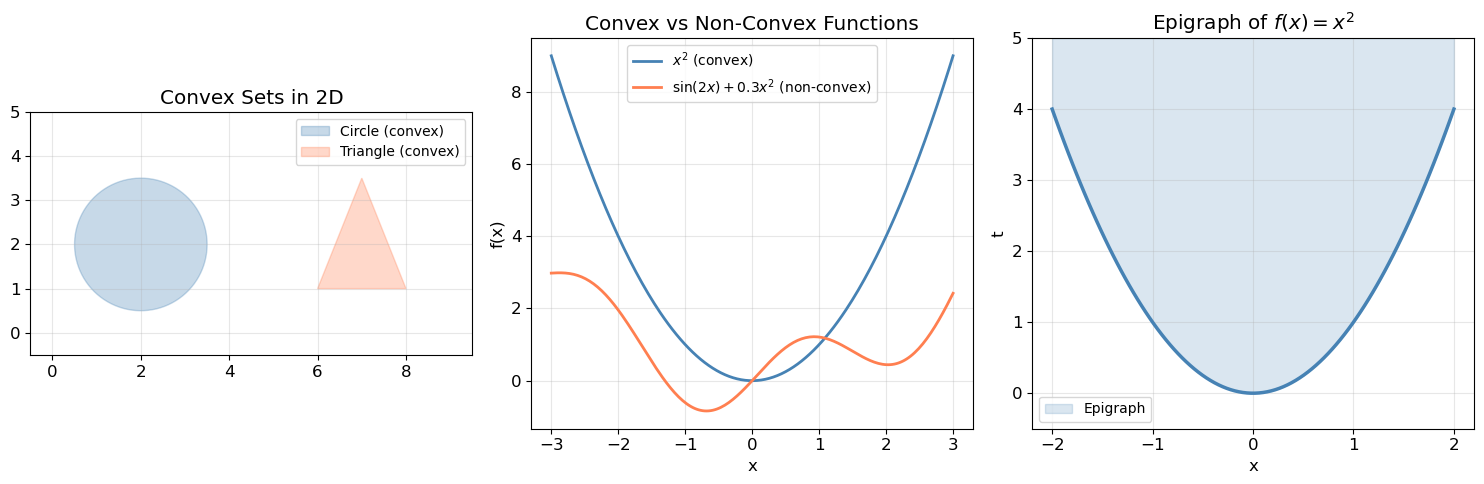

In [17]:
# =============================================================================
# SECTION 9: Convex Sets Visualization (2D)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Convex sets examples
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 100)

# Circle (convex)
ax.fill(2 + 1.5*np.cos(theta), 2 + 1.5*np.sin(theta), alpha=0.3, color=COLOR_PRIMARY, label='Circle (convex)')
# Triangle (convex)
tri_x = [6, 8, 7]
tri_y = [1, 1, 3.5]
ax.fill(tri_x + [tri_x[0]], tri_y + [tri_y[0]], alpha=0.3, color=COLOR_SECONDARY, label='Triangle (convex)')

ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-0.5, 5)
ax.set_title('Convex Sets in 2D')
ax.legend(fontsize=10)
ax.set_aspect('equal')

# Plot 2: Convex vs non-convex function
ax = axes[1]
x_plot = np.linspace(-3, 3, 200)
ax.plot(x_plot, x_plot**2, color=COLOR_PRIMARY, label=r'$x^2$ (convex)')
ax.plot(x_plot, np.sin(2*x_plot) + 0.3*x_plot**2, color=COLOR_SECONDARY,
        label=r'$\sin(2x)+0.3x^2$ (non-convex)')
ax.set_title('Convex vs Non-Convex Functions')
ax.legend(fontsize=10)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')

# Plot 3: Epigraph
ax = axes[2]
x_epi = np.linspace(-2, 2, 100)
y_epi = x_epi**2
ax.fill_between(x_epi, y_epi, 5, alpha=0.2, color=COLOR_PRIMARY, label='Epigraph')
ax.plot(x_epi, y_epi, color=COLOR_PRIMARY, linewidth=2.5)
ax.set_title(r'Epigraph of $f(x)=x^2$')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_ylim(-0.5, 5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

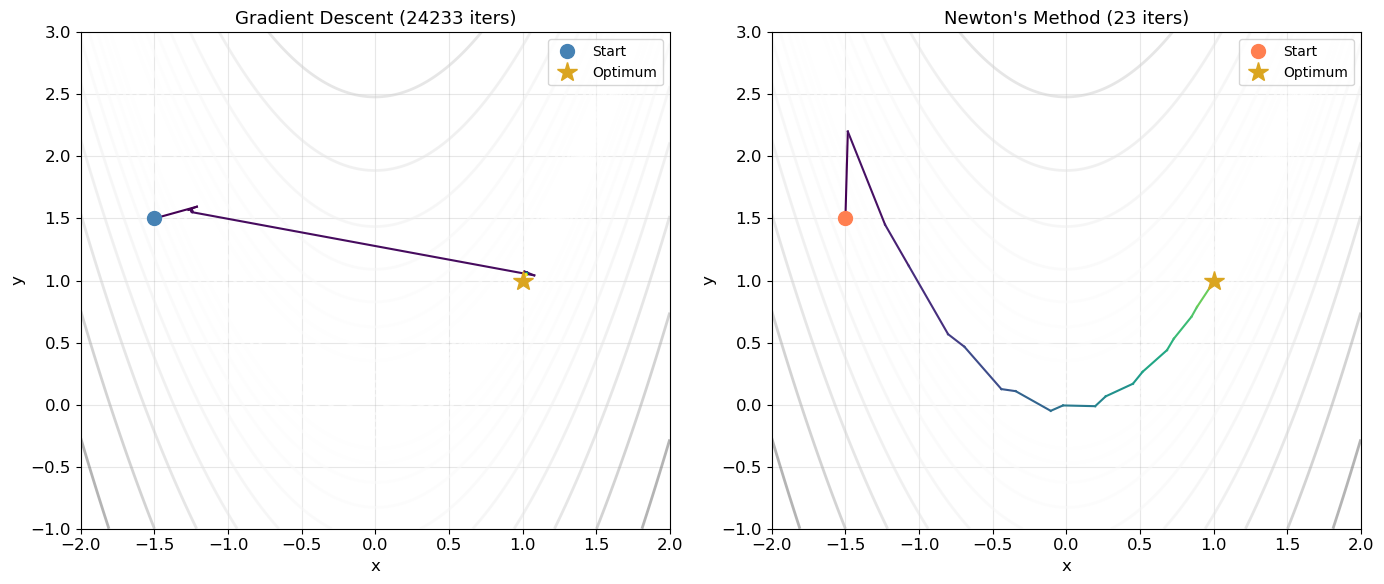

In [18]:
# =============================================================================
# SECTION 9: GD vs Newton Convergence Paths on Rosenbrock Contours
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Contour plot
x_range = np.linspace(-2, 2, 300)
y_range = np.linspace(-1, 3, 300)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = (1 - X_mesh)**2 + 100*(Y_mesh - X_mesh**2)**2

for idx, (path, name, color) in enumerate([
    (gd_x, 'Gradient Descent', COLOR_PRIMARY),
    (nt_x, "Newton's Method", COLOR_SECONDARY)
]):
    ax = axes[idx]
    levels = np.logspace(-1, 3.5, 20)
    ax.contour(X_mesh, Y_mesh, Z_mesh, levels=levels, cmap='gray_r', alpha=0.5)

    path_arr = np.array(path)
    n_pts = min(len(path_arr), 500)
    colors = plt.cm.get_cmap(CMAP_EVOLUTION)(np.linspace(0, 1, n_pts))
    for i in range(n_pts - 1):
        ax.plot(path_arr[i:i+2, 0], path_arr[i:i+2, 1], '-', color=colors[i], linewidth=1.5)

    ax.plot(path_arr[0, 0], path_arr[0, 1], 'o', color=color, markersize=10, label='Start')
    ax.plot(1, 1, '*', color=COLOR_ACCENT, markersize=15, label='Optimum')
    ax.set_title(f'{name} ({len(path)} iters)', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=10)
    ax.set_xlim([-2, 2])
    ax.set_ylim([-1, 3])

plt.tight_layout()
plt.show()

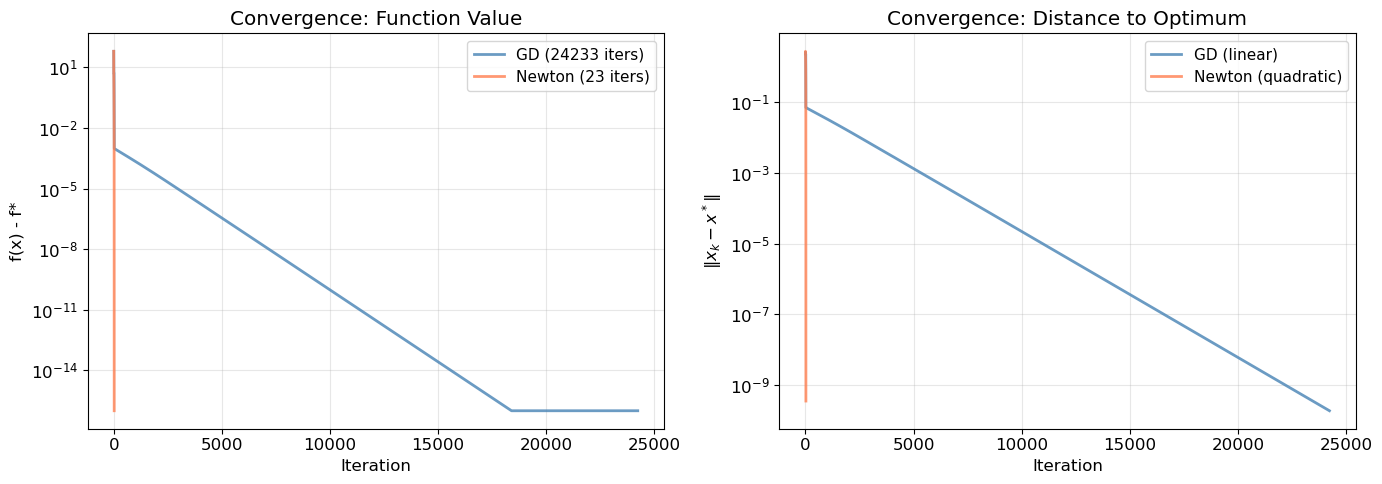

In [19]:
# =============================================================================
# SECTION 9: Convergence Rate Comparison
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Function value convergence
ax = axes[0]
ax.semilogy(range(len(gd_f)), [max(v, 1e-16) for v in gd_f], color=COLOR_PRIMARY,
            label=f'GD ({len(gd_f)} iters)', alpha=0.8)
ax.semilogy(range(len(nt_f)), [max(v, 1e-16) for v in nt_f], color=COLOR_SECONDARY,
            label=f'Newton ({len(nt_f)} iters)', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('f(x) - f*')
ax.set_title('Convergence: Function Value')
ax.legend(fontsize=11)

# Error convergence
ax = axes[1]
gd_errs_plot = [max(np.linalg.norm(np.array(x) - x_true), 1e-16) for x in gd_x]
nt_errs_plot = [max(np.linalg.norm(np.array(x) - x_true), 1e-16) for x in nt_x]

ax.semilogy(range(len(gd_errs_plot)), gd_errs_plot, color=COLOR_PRIMARY,
            label='GD (linear)', alpha=0.8)
ax.semilogy(range(len(nt_errs_plot)), nt_errs_plot, color=COLOR_SECONDARY,
            label='Newton (quadratic)', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|x_k - x^*\|$')
ax.set_title('Convergence: Distance to Optimum')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

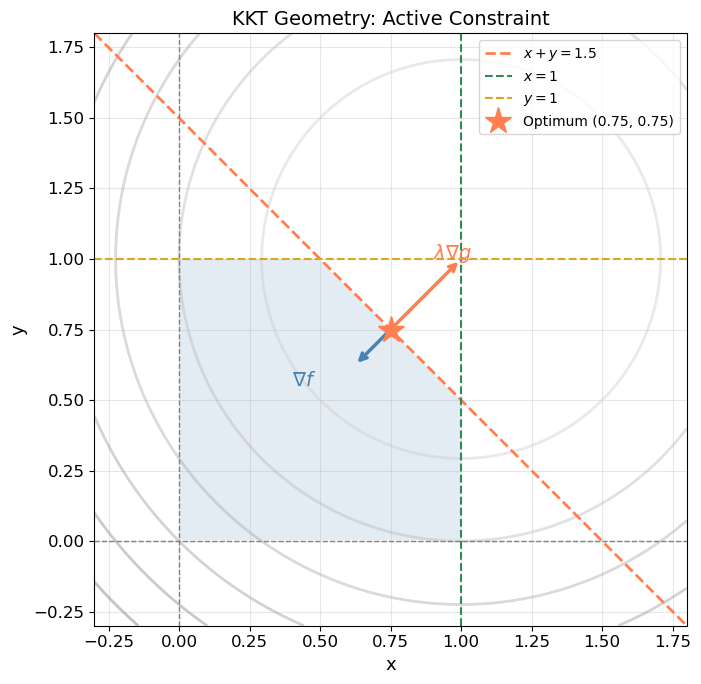

In [20]:
# =============================================================================
# SECTION 9: KKT Geometry — Active Constraints
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Simple 2D QP: min 0.5(x^2 + y^2) - x - y  s.t. x+y<=1.5, x<=1, y<=1, x>=0, y>=0
x_range = np.linspace(-0.3, 1.8, 200)
y_range = np.linspace(-0.3, 1.8, 200)
X_kkt, Y_kkt = np.meshgrid(x_range, y_range)
Z_kkt = 0.5*(X_kkt**2 + Y_kkt**2) - X_kkt - Y_kkt

# Feasible region
feasible = (X_kkt + Y_kkt <= 1.5) & (X_kkt <= 1) & (Y_kkt <= 1) & (X_kkt >= 0) & (Y_kkt >= 0)
Z_masked = np.where(feasible, Z_kkt, np.nan)

levels = np.linspace(-1.5, 2, 15)
cs = ax.contour(X_kkt, Y_kkt, Z_kkt, levels=levels, cmap='gray_r', alpha=0.4)
ax.contourf(X_kkt, Y_kkt, np.where(feasible, 1, np.nan), levels=[0.5, 1.5],
            colors=[COLOR_PRIMARY], alpha=0.15)

# Constraint boundaries
ax.plot(x_range, 1.5 - x_range, '--', color=COLOR_SECONDARY, label=r'$x+y=1.5$', linewidth=2)
ax.axvline(x=1, color=COLOR_TERTIARY, linestyle='--', label=r'$x=1$', linewidth=1.5)
ax.axhline(y=1, color=COLOR_ACCENT, linestyle='--', label=r'$y=1$', linewidth=1.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Optimal point (unconstrained: x=y=1, but x+y<=1.5, so constrained)
x_opt_kkt = np.array([0.75, 0.75])
ax.plot(x_opt_kkt[0], x_opt_kkt[1], '*', color=COLOR_SECONDARY, markersize=20,
        zorder=5, label=f'Optimum ({x_opt_kkt[0]:.2f}, {x_opt_kkt[1]:.2f})')

# Gradient at optimum
grad_at_opt = x_opt_kkt - np.array([1.0, 1.0])
ax.annotate('', xy=x_opt_kkt + 0.5*grad_at_opt, xytext=x_opt_kkt,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRIMARY, lw=2.5))
ax.text(x_opt_kkt[0] - 0.35, x_opt_kkt[1] - 0.2, r'$\nabla f$', fontsize=14, color=COLOR_PRIMARY)

# Normal to active constraint
ax.annotate('', xy=x_opt_kkt + 0.35*np.array([1, 1])/np.sqrt(2),
            xytext=x_opt_kkt,
            arrowprops=dict(arrowstyle='->', color=COLOR_SECONDARY, lw=2.5))
ax.text(x_opt_kkt[0] + 0.15, x_opt_kkt[1] + 0.25, r'$\lambda \nabla g$', fontsize=14, color=COLOR_SECONDARY)

ax.set_xlim(-0.3, 1.8)
ax.set_ylim(-0.3, 1.8)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('KKT Geometry: Active Constraint', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

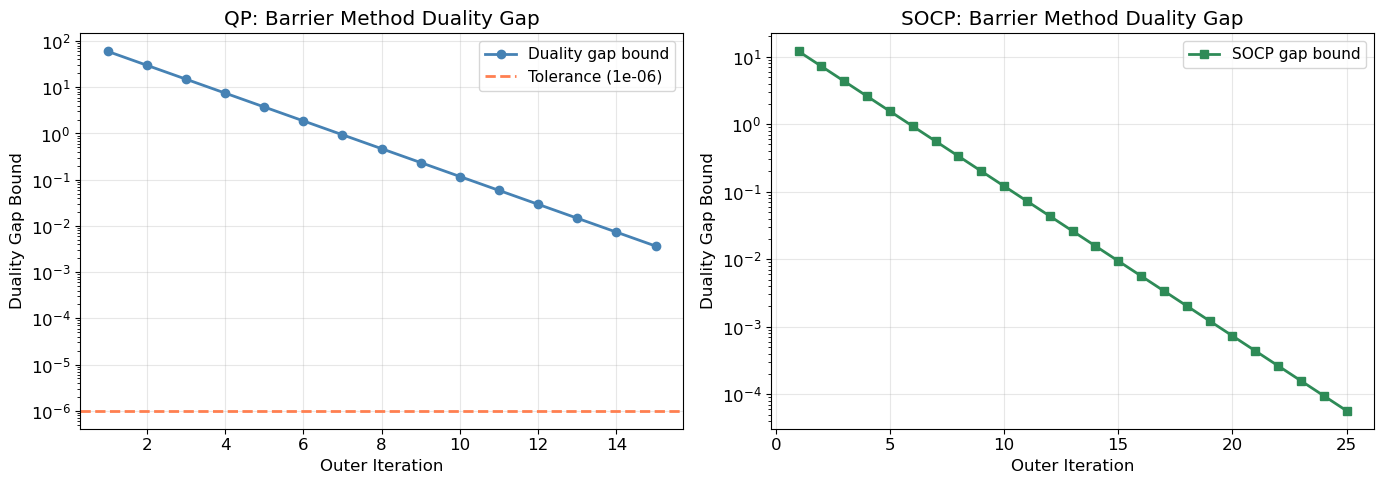

In [21]:
# =============================================================================
# SECTION 9: Duality Gap Convergence
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QP barrier duality gap
ax = axes[0]
ax.semilogy(range(1, len(barrier_gaps)+1), barrier_gaps, 'o-', color=COLOR_PRIMARY,
            markersize=6, label='Duality gap bound')
ax.axhline(y=TOL_DUALITY, color=COLOR_SECONDARY, linestyle='--', label=f'Tolerance ({TOL_DUALITY})')
ax.set_xlabel('Outer Iteration')
ax.set_ylabel('Duality Gap Bound')
ax.set_title('QP: Barrier Method Duality Gap')
ax.legend(fontsize=11)

# SOCP localization gap
ax = axes[1]
if len(loc_gaps) > 0:
    ax.semilogy(range(1, len(loc_gaps)+1), loc_gaps, 's-', color=COLOR_TERTIARY,
                markersize=6, label='SOCP gap bound')
    ax.set_xlabel('Outer Iteration')
    ax.set_ylabel('Duality Gap Bound')
    ax.set_title('SOCP: Barrier Method Duality Gap')
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

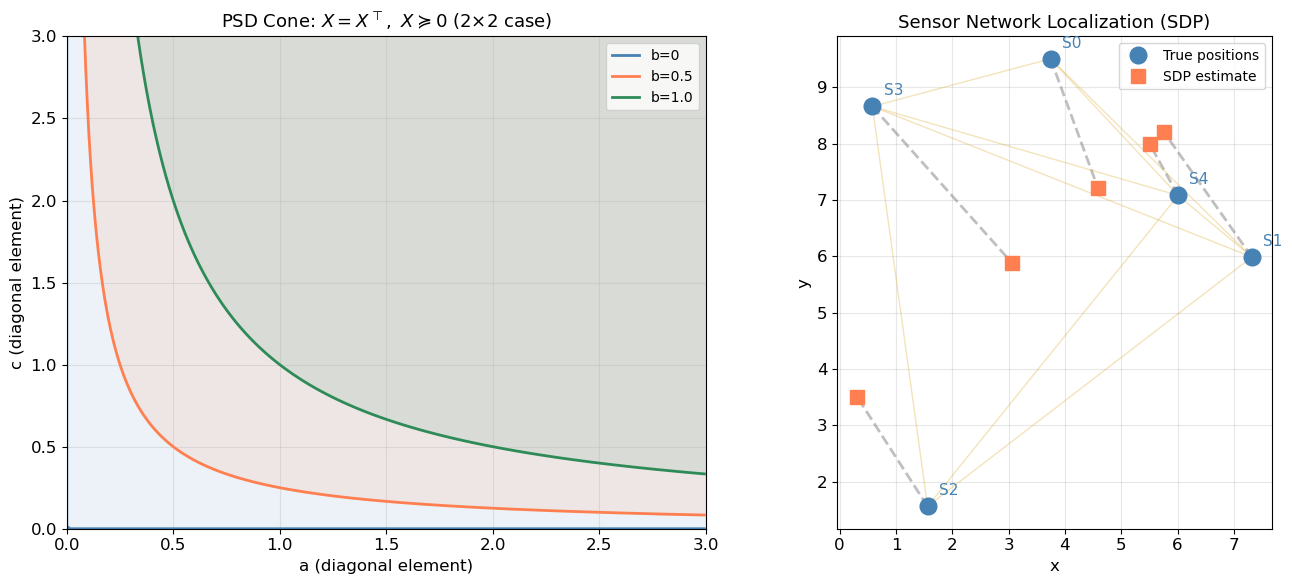

In [22]:
# =============================================================================
# SECTION 9: SDP Feasible Region Illustration & Sensor Localization
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PSD cone in 2D symmetric matrices: X = [[a,b],[b,c]], X >= 0 iff a>=0, c>=0, ac-b^2>=0
ax = axes[0]
a_vals = np.linspace(0, 3, 200)
c_vals = np.linspace(0, 3, 200)
A_psd, C_psd = np.meshgrid(a_vals, c_vals)

# For each (a,c), the range of b is [-sqrt(ac), sqrt(ac)]
# We'll plot the (a,c) slice at b=0: feasible iff a>=0, c>=0
# And show the boundary ac = b^2 for a specific b
for b_val, color, label in [(0.0, COLOR_PRIMARY, 'b=0'), (0.5, COLOR_SECONDARY, 'b=0.5'),
                              (1.0, COLOR_TERTIARY, 'b=1.0')]:
    feasible_psd = (A_psd * C_psd >= b_val**2)
    ax.contour(A_psd, C_psd, (A_psd * C_psd - b_val**2).astype(float),
               levels=[0], colors=[color], linewidths=2)
    ax.contourf(A_psd, C_psd, np.where(A_psd * C_psd >= b_val**2, 1.0, 0.0),
                levels=[0.5, 1.5], colors=[color], alpha=0.1)

ax.set_xlabel('a (diagonal element)', fontsize=12)
ax.set_ylabel('c (diagonal element)', fontsize=12)
ax.set_title(r'PSD Cone: $X = X^\top,\ X \succeq 0$ (2$\times$2 case)', fontsize=13)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=COLOR_PRIMARY, linewidth=2, label='b=0'),
                   Line2D([0], [0], color=COLOR_SECONDARY, linewidth=2, label='b=0.5'),
                   Line2D([0], [0], color=COLOR_TERTIARY, linewidth=2, label='b=1.0')]
ax.legend(handles=legend_elements, fontsize=10)

# Sensor localization result
ax = axes[1]
ax.plot(positions_true[:, 0], positions_true[:, 1], 'o', color=COLOR_PRIMARY,
        markersize=12, label='True positions', zorder=5)
ax.plot(P_aligned[:, 0], P_aligned[:, 1], 's', color=COLOR_SECONDARY,
        markersize=10, label='SDP estimate', zorder=5)

for i in range(n_sensors):
    ax.plot([positions_true[i, 0], P_aligned[i, 0]],
            [positions_true[i, 1], P_aligned[i, 1]],
            '--', color='gray', alpha=0.5)
    ax.annotate(f'S{i}', positions_true[i] + 0.2, fontsize=11, color=COLOR_PRIMARY)

# Draw edges
for i_e, j_e in edges:
    ax.plot([positions_true[i_e, 0], positions_true[j_e, 0]],
            [positions_true[i_e, 1], positions_true[j_e, 1]],
            '-', color=COLOR_ACCENT, alpha=0.3, linewidth=1)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Sensor Network Localization (SDP)', fontsize=13)
ax.legend(fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 10. Extensions & Advanced Topics

### ADMM (Alternating Direction Method of Multipliers)

ADMM solves problems of the form:

$$\min \; f(x) + g(z) \quad \text{s.t.} \; Ax + Bz = c$$

The updates are:

$$\boxed{
\begin{aligned}
x^{k+1} &= \arg\min_x \left( f(x) + \frac{\rho}{2}\|Ax + Bz^k - c + u^k\|_2^2 \right) \\
z^{k+1} &= \arg\min_z \left( g(z) + \frac{\rho}{2}\|Ax^{k+1} + Bz - c + u^k\|_2^2 \right) \\
u^{k+1} &= u^k + Ax^{k+1} + Bz^{k+1} - c
\end{aligned}
}$$

### Proximal Gradient Method

For $\min f(x) + g(x)$ where $f$ is smooth and $g$ is proximable:

$$x^{k+1} = \text{prox}_{tg}(x^k - t\nabla f(x^k))$$

Common proximal operators:
- $g(x) = \lambda\|x\|_1$: **soft thresholding** $\text{prox}(v)_i = \text{sign}(v_i)\max(|v_i|-\lambda t, 0)$
- $g(x) = I_C(x)$ (indicator): **projection** onto $C$

### Disciplined Convex Programming (DCP)

DCP is a set of **composition rules** that verify convexity automatically:
- convex $\circ$ affine = convex
- convex + convex = convex
- convex nondecreasing $\circ$ convex = convex
- concave nonincreasing $\circ$ convex = convex

### Connections to Robust Control

- **$\mathcal{H}_\infty$ control** reduces to LMI (SDP) feasibility
- **Lyapunov stability** analysis via SDP: find $P \succ 0$ s.t. $A^T P + PA \prec 0$
- **System identification** with convex constraints

In [23]:
# =============================================================================
# SECTION 10: ADMM for LASSO (L1-Regularized Least Squares)
# =============================================================================

def admm_lasso(A_mat, b_vec, lam_reg, rho=1.0, max_iter=500, tol=1e-6):
    """Solve LASSO: min 0.5||Ax-b||^2 + lam*||x||_1 via ADMM.

    ADMM splitting: min 0.5||Ax-b||^2 + lam||z||_1  s.t. x = z

    Args:
        A_mat: Design matrix. Shape: (m, n).
        b_vec: Observation vector. Shape: (m,).
        lam_reg: L1 regularization parameter.
        rho: ADMM penalty parameter.
        max_iter: Maximum ADMM iterations.
        tol: Primal/dual residual tolerance.

    Returns:
        x_opt: Optimal solution. Shape: (n,).
        history: Dict with primal_res, dual_res lists.
    """
    m, n = A_mat.shape
    # Precompute
    AtA = A_mat.T @ A_mat
    Atb = A_mat.T @ b_vec
    L_factor = np.linalg.cholesky(AtA + rho * np.eye(n))

    x = np.zeros(n)
    z = np.zeros(n)
    u = np.zeros(n)

    history = {'primal_res': [], 'dual_res': []}

    def soft_threshold(v, kappa):
        return np.sign(v) * np.maximum(np.abs(v) - kappa, 0)

    for k in range(max_iter):
        # x-update: (AtA + rho I) x = Atb + rho(z - u)
        rhs = Atb + rho * (z - u)
        x = la.cho_solve((L_factor, True), rhs)

        # z-update: soft thresholding
        z_old = z.copy()
        z = soft_threshold(x + u, lam_reg / rho)

        # u-update
        u = u + x - z

        # Residuals
        primal_res = np.linalg.norm(x - z)
        dual_res = np.linalg.norm(rho * (z - z_old))
        history['primal_res'].append(primal_res)
        history['dual_res'].append(dual_res)

        if primal_res < tol and dual_res < tol:
            break

    return z, history


# Test ADMM LASSO
np.random.seed(SEED)
m_lasso, n_lasso = 100, 200
A_lasso = np.random.randn(m_lasso, n_lasso) / np.sqrt(m_lasso)
x_true_lasso = np.zeros(n_lasso)
x_true_lasso[:10] = np.random.randn(10)  # sparse ground truth
b_lasso = A_lasso @ x_true_lasso + 0.1 * np.random.randn(m_lasso)
lam_lasso = 0.1

x_admm, admm_hist = admm_lasso(A_lasso, b_lasso, lam_lasso, rho=1.0, max_iter=1000)

# Compare with scipy
def lasso_obj(x):
    return 0.5 * np.linalg.norm(A_lasso @ x - b_lasso)**2 + lam_lasso * np.linalg.norm(x, 1)

obj_admm = lasso_obj(x_admm)
print(f"ADMM LASSO: {len(admm_hist['primal_res'])} iterations")
print(f"Objective value: {obj_admm:.6f}")
print(f"Nonzero coefficients: {np.sum(np.abs(x_admm) > 1e-4)} (true: 10)")
print(f"Recovery error: {np.linalg.norm(x_admm - x_true_lasso):.4f}")

ADMM LASSO: 70 iterations
Objective value: 1.329276
Nonzero coefficients: 43 (true: 10)
Recovery error: 1.0149


In [24]:
# =============================================================================
# SECTION 10: Proximal Gradient for LASSO comparison
# =============================================================================

def proximal_gradient_lasso(A_mat, b_vec, lam_reg, max_iter=2000, tol=1e-6):
    """Solve LASSO via proximal gradient (ISTA).

    Args:
        A_mat: Design matrix. Shape: (m, n).
        b_vec: Observation vector. Shape: (m,).
        lam_reg: L1 regularization parameter.
        max_iter: Maximum iterations.
        tol: Convergence tolerance.

    Returns:
        x_opt: Optimal solution. Shape: (n,).
        obj_hist: List of objective values.
    """
    m, n = A_mat.shape
    AtA = A_mat.T @ A_mat
    Atb = A_mat.T @ b_vec

    # Step size: 1/L where L = largest eigenvalue of AtA
    L = np.linalg.eigvalsh(AtA)[-1]
    t = 1.0 / L

    x = np.zeros(n)
    obj_hist = []

    def soft_threshold(v, kappa):
        return np.sign(v) * np.maximum(np.abs(v) - kappa, 0)

    for k in range(max_iter):
        grad = AtA @ x - Atb
        x_new = soft_threshold(x - t * grad, lam_reg * t)

        obj = 0.5 * np.linalg.norm(A_mat @ x_new - b_vec)**2 + lam_reg * np.linalg.norm(x_new, 1)
        obj_hist.append(obj)

        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new

    return x, obj_hist


x_prox, prox_hist = proximal_gradient_lasso(A_lasso, b_lasso, lam_lasso, max_iter=3000)

print(f"Proximal Gradient: {len(prox_hist)} iterations")
print(f"Objective value: {lasso_obj(x_prox):.6f}")
print(f"ADMM vs ProxGrad objective difference: {abs(obj_admm - lasso_obj(x_prox)):.2e}")

Proximal Gradient: 380 iterations
Objective value: 1.329276
ADMM vs ProxGrad objective difference: 8.74e-11


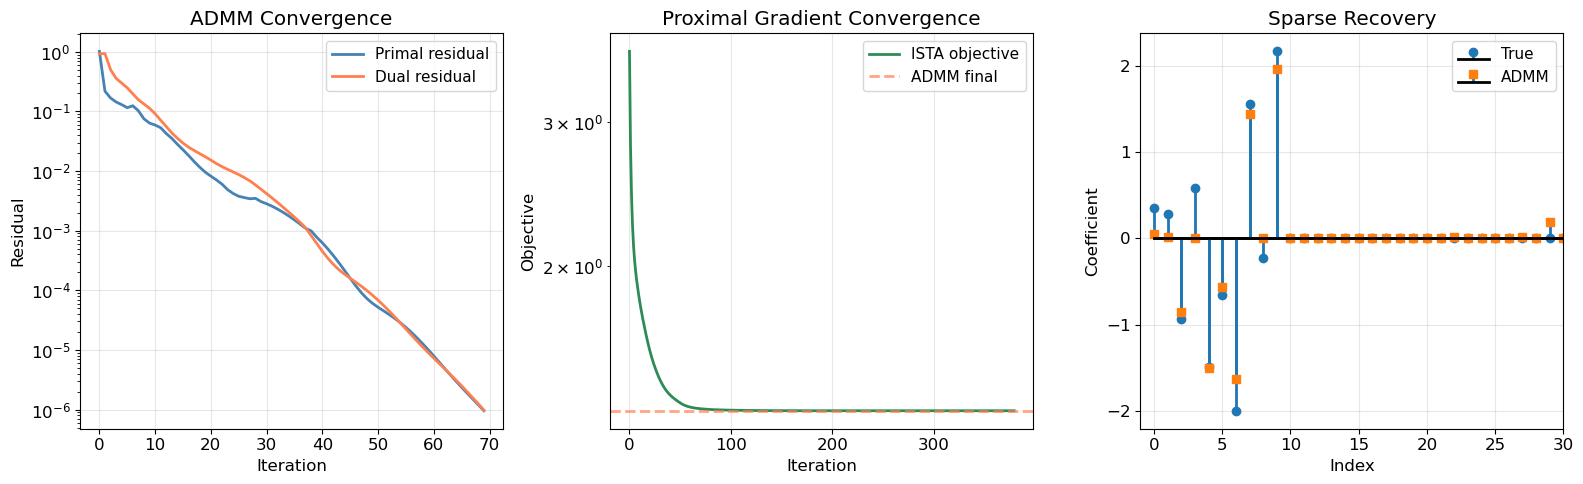

In [25]:
# =============================================================================
# SECTION 10: ADMM Convergence Visualization
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ADMM residuals
ax = axes[0]
ax.semilogy(admm_hist['primal_res'], color=COLOR_PRIMARY, label='Primal residual')
ax.semilogy(admm_hist['dual_res'], color=COLOR_SECONDARY, label='Dual residual')
ax.set_xlabel('Iteration')
ax.set_ylabel('Residual')
ax.set_title('ADMM Convergence')
ax.legend(fontsize=11)

# Proximal gradient convergence
ax = axes[1]
ax.semilogy(prox_hist, color=COLOR_TERTIARY, label='ISTA objective')
ax.axhline(y=obj_admm, color=COLOR_SECONDARY, linestyle='--', label='ADMM final', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective')
ax.set_title('Proximal Gradient Convergence')
ax.legend(fontsize=11)

# Sparse recovery comparison
ax = axes[2]
ax.stem(np.arange(n_lasso), x_true_lasso, linefmt='-', markerfmt='o', basefmt='k-',
        label='True')
ax.stem(np.arange(n_lasso), x_admm, linefmt='-', markerfmt='s', basefmt='k-',
        label='ADMM')
ax.set_xlabel('Index')
ax.set_ylabel('Coefficient')
ax.set_title('Sparse Recovery')
ax.legend(fontsize=11)
ax.set_xlim(-1, 30)

plt.tight_layout()
plt.show()

---
## Summary

| Method | Problem Class | Convergence | Key Property |
|--------|--------------|-------------|--------------|
| Gradient Descent | Unconstrained smooth | Linear | Simple, scalable |
| Newton's Method | Unconstrained smooth | Quadratic | Fast near optimum |
| Active-Set QP | Quadratic programs | Finite | Exact for QP |
| Barrier Method | Conic programs (LP/QP/SOCP/SDP) | $O(1/t)$ | General-purpose |
| ADMM | Composite/distributed | $O(1/k)$ | Splitting, scalable |
| Proximal Gradient | Composite (smooth + nonsmooth) | $O(1/k)$ to $O(1/k^2)$ | Handles nonsmooth terms |

### Key Takeaways

$$\boxed{\text{Convexity} \implies \text{Local optimum = Global optimum} \implies \text{Efficient algorithms}}$$

1. **Always check convexity first** — Hessian PSD, composition rules (DCP)
2. **Duality provides certificates** — lower bounds, sensitivity, complementary slackness
3. **Choose the right solver** — match problem structure to algorithm
4. **Interior-point methods are polynomial** — practical for moderate-size problems
5. **First-order methods scale** — ADMM, proximal gradient for large-scale problems

### References

1. Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press.
2. Boyd, S., Parikh, N., Chu, E., Peleato, B., & Eckstein, J. (2011). *Distributed Optimization and Statistical Learning via ADMM*. Foundations and Trends in ML.
3. Nesterov, Y. (2004). *Introductory Lectures on Convex Optimization*. Springer.
4. Ben-Tal, A., & Nemirovski, A. (2001). *Lectures on Modern Convex Optimization*. SIAM.